# Etapa 5 — Modelagem Numérica: Volume Mensal de Notícias sobre Elétrico (SHAP + Conformal Prediction)

**Disciplina:** Perspectiva em Ciência de Dados
**Projeto 2:** Análise de notícias de carro do Motor1 (2016–2026)

---

## Pergunta-guia do projeto

> **A cobertura de imprensa do Motor1 antecipou ou só acompanhou a transição elétrica no mercado automotivo brasileiro?**

## Objetivo desta etapa

Nas etapas anteriores olhamos a proporção de cobertura por ano (Etapa 1) e por marca (Etapa 3). Aqui damos um passo a mais: tentamos **prever o volume mensal de notícias sobre elétrico** a partir de características do próprio mês (ano, mês, quantas marcas diferentes apareceram, quantos autores diferentes escreveram, etc.), e usamos **SHAP** para entender quais desses fatores mais pesam na previsão.

Além do modelo de previsão, adicionamos **conformal prediction**: em vez de só um número de previsão, o modelo entrega um **intervalo** ("entre X e Y notícias, com 90% de confiança") — uma forma estatisticamente rigorosa de comunicar incerteza, sem exigir suposições fortes sobre a distribuição dos erros (diferente de um intervalo de confiança clássico baseado em normalidade).

**Nota de escopo:** o plano original desta etapa também cogitava um modelo de difusão via VAE para modelar a distribuição dos volumes. Optamos por não incluir essa parte — com apenas 120 observações mensais (10 anos × 12 meses), um modelo generativo profundo como VAE/difusão não tem dados suficientes para treinar de forma confiável, e o retorno para a pergunta-guia do projeto seria baixo perto do risco de implementação em pouco tempo. Preferimos manter o modelo simples (árvore de decisão) e interpretável, e investir esse tempo em fazer o SHAP e o conformal prediction corretamente.

---
## 1. Importações

In [1]:
import os
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from unidecode import unidecode

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import shap
from mapie.regression import SplitConformalRegressor

RANDOM_STATE = 42

_NOTEBOOK_DIR = os.path.dirname(os.path.abspath("__file__"))
DATA_DIR = os.path.normpath(os.path.join(_NOTEBOOK_DIR, "..", "..", "dados"))
ARQUIVO_NOTICIAS = os.path.join(DATA_DIR, "noticias_motor1_2016_2026.csv")
ARQUIVO_SAIDA = os.path.join(DATA_DIR, "modelagem_volume_mensal.csv")

C:\Users\muvil\projeto-2-de-perspectiva-em-ciencia-de-dados\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## 2. Preparando os dados: texto, termo "elétrico" e marca por notícia

Reaproveitamos exatamente a mesma lógica de normalização de texto e o mesmo regex de "elétrico" das etapas anteriores, e a mesma lista de marcas do notebook `cruzamento_marca.ipynb`, para manter consistência entre os notebooks do projeto.

In [2]:
def limpar_texto(texto):
    texto = str(texto).lower()
    texto = unidecode(texto)
    texto = re.sub(r"[^a-z0-9\s]", " ", texto)
    return texto


df = pd.read_csv(ARQUIVO_NOTICIAS, parse_dates=["data_publicacao"])
df["ano"] = df["data_publicacao"].dt.year
df["mes"] = df["data_publicacao"].dt.month

df["titulo_limpo"] = df["titulo"].fillna("").apply(limpar_texto)
df["texto_limpo"] = (
    df["titulo"].fillna("") + " " + df["subtitulo"].fillna("") + " " + df["texto_completo"].fillna("")
).apply(limpar_texto)

df["menciona_eletrico"] = df["texto_limpo"].str.contains(
    r"carro eletric|carros eletric|veiculo eletric|veiculos eletric|"
    r"motor eletric|motores eletric|100% eletric|totalmente eletric|"
    r"puramente eletric|eletrificaca|eletrificad|autonomia eletrica|"
    r"bateria eletric|carro a bateria|sedan eletric|suv eletric|"
    r"picape eletric|hatch eletric",
    regex=True,
)

MARCAS = {
    "volkswagen": r"\bvolkswagen\b|\bvw\b", "chevrolet": r"\bchevrolet\b|\bgm\b", "fiat": r"\bfiat\b",
    "ford": r"\bford\b", "toyota": r"\btoyota\b", "honda": r"\bhonda\b", "hyundai": r"\bhyundai\b",
    "renault": r"\brenault\b", "nissan": r"\bnissan\b", "jeep": r"\bjeep\b", "peugeot": r"\bpeugeot\b",
    "citroen": r"\bcitroen\b", "bmw": r"\bbmw\b", "mercedes-benz": r"\bmercedes\b", "audi": r"\baudi\b",
    "volvo": r"\bvolvo\b", "kia": r"\bkia\b", "mitsubishi": r"\bmitsubishi\b", "subaru": r"\bsubaru\b",
    "land rover": r"\bland rover\b|\brange rover\b", "porsche": r"\bporsche\b", "ferrari": r"\bferrari\b",
    "lamborghini": r"\blamborghini\b", "maserati": r"\bmaserati\b", "jaguar": r"\bjaguar\b", "mini": r"\bmini\b",
    "suzuki": r"\bsuzuki\b", "byd": r"\bbyd\b", "gwm": r"\bgwm\b|\bgreat wall\b|\bhaval\b",
    "caoa chery": r"\bchery\b", "ram": r"\bram\b", "dodge": r"\bdodge\b", "chrysler": r"\bchrysler\b",
    "lexus": r"\blexus\b", "tesla": r"\btesla\b", "alfa romeo": r"\balfa romeo\b", "skoda": r"\bskoda\b",
    "jac": r"\bjac\b", "troller": r"\btroller\b", "mg": r"\bmg\b",
}


def marca_do_titulo(titulo):
    for nome, padrao in MARCAS.items():
        if re.search(padrao, titulo):
            return nome
    return None


df["marca"] = df["titulo_limpo"].apply(marca_do_titulo)
print(f"Total de notícias: {len(df)}")

Total de notícias: 26917


---
## 3. Agregando por mês: a unidade de análise desta etapa

Cada linha da base final é um **mês** (ano + mês), não mais uma notícia individual. As features (variáveis explicativas) resumem o que aconteceu naquele mês:

- `ano`, `mes_sin`, `mes_cos`: quando foi (o mês é codificado em seno/cosseno para capturar sazonalidade circular — dezembro e janeiro ficam "próximos", diferente de usar o número do mês cru)
- `total_noticias`: quantas notícias saíram no mês (controla o volume geral: mais notícias no geral tende a significar mais notícias sobre qualquer assunto específico também)
- `n_marcas_distintas`, `n_autores_distintos`: diversidade de marcas e autores cobertos no mês
- `marca_lider` (virou colunas *dummy*) e `vol_marca_lider`: qual marca mais apareceu no mês e quantas vezes

O alvo (`qtd_eletrico`) é quantas notícias daquele mês mencionam elétrico.

In [3]:
mensal = df.groupby(["ano", "mes"]).agg(
    qtd_eletrico=("menciona_eletrico", "sum"),
    total_noticias=("id_noticia", "count"),
    n_marcas_distintas=("marca", "nunique"),
    n_autores_distintos=("autor", "nunique"),
).reset_index()


def marca_lider_do_mes(grupo):
    contagem = grupo["marca"].value_counts()
    if len(contagem) == 0:
        return pd.Series({"marca_lider": None, "vol_marca_lider": 0})
    return pd.Series({"marca_lider": contagem.index[0], "vol_marca_lider": contagem.iloc[0]})


lider_mensal = (
    df.groupby(["ano", "mes"])
      .apply(marca_lider_do_mes, include_groups=False)
      .reset_index()
)
mensal = mensal.merge(lider_mensal, on=["ano", "mes"])

mensal["mes_sin"] = np.sin(2 * np.pi * mensal["mes"] / 12)
mensal["mes_cos"] = np.cos(2 * np.pi * mensal["mes"] / 12)

# 2026 é ano incompleto na coleta -- mesmo critério das etapas anteriores
mensal = mensal[mensal["ano"] <= 2025].reset_index(drop=True)

print(f"Total de meses na base: {len(mensal)} (esperado: 10 anos x 12 meses = 120)")
mensal.head()

Total de meses na base: 120 (esperado: 10 anos x 12 meses = 120)


,ano,mes,qtd_eletrico,total_noticias,n_marcas_distintas,n_autores_distintos,marca_lider,vol_marca_lider,mes_sin,mes_cos
0,2016,1,0,32,12,7,bmw,5,0.500000,8.660254e-01
1,2016,2,0,31,13,5,fiat,4,0.866025,5.000000e-01
2,2016,3,0,26,13,6,volkswagen,4,1.000000,6.123234e-17
3,2016,4,0,26,12,7,fiat,3,0.866025,-5.000000e-01
4,2016,5,0,37,16,7,chevrolet,5,0.500000,-8.660254e-01


In [4]:
marca_dummies = pd.get_dummies(mensal["marca_lider"], prefix="lider")
mensal_final = pd.concat([mensal, marca_dummies], axis=1)

FEATURE_COLS = (
    ["ano", "mes_sin", "mes_cos", "total_noticias", "n_marcas_distintas", "n_autores_distintos", "vol_marca_lider"]
    + list(marca_dummies.columns)
)

X = mensal_final[FEATURE_COLS]
y = mensal_final["qtd_eletrico"]

print(f"{len(FEATURE_COLS)} features: {FEATURE_COLS}")

16 features: ['ano', 'mes_sin', 'mes_cos', 'total_noticias', 'n_marcas_distintas', 'n_autores_distintos', 'vol_marca_lider', 'lider_audi', 'lider_bmw', 'lider_chevrolet', 'lider_fiat', 'lider_ford', 'lider_honda', 'lider_nissan', 'lider_toyota', 'lider_volkswagen']


---
## 4. Separando treino / calibração / teste

Usamos uma divisão **aleatória** (não estritamente cronológica) entre treino, calibração e teste. Isso é uma escolha metodológica consciente: como `ano` já é uma feature explícita do modelo, ele consegue **interpolar** a tendência de crescimento entre os anos que já viu, em vez de precisar **extrapolar** para além do que observou — o que modelos de árvore (como o Random Forest que usamos aqui) não fazem bem. Testamos isso na prática: com uma divisão cronológica estrita (treinar só em 2016–2021 e testar em 2024–2025), o modelo teve desempenho muito ruim (R² negativo), porque nunca tinha visto volumes tão altos quanto os de 2024-2025 durante o treino. Com a divisão aleatória, o modelo vê exemplos de todos os anos durante o treino, e o objetivo passa a ser **explicativo** (quais fatores se associam ao volume) em vez de **previsão estrita do futuro** — o que é justamente o que o SHAP faz.

In [5]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=RANDOM_STATE)
X_calib, X_test, y_calib, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE)

print(f"Treino: {len(X_train)} meses | Calibração: {len(X_calib)} meses | Teste: {len(X_test)} meses")

Treino: 72 meses | Calibração: 24 meses | Teste: 24 meses


---
## 5. Modelo: Random Forest Regressor

Comparamos com um baseline ingênuo (prever sempre a média histórica do treino), para ter certeza de que o modelo está realmente aprendendo algo além de "chutar a média".

In [6]:
modelo_rf = RandomForestRegressor(n_estimators=300, max_depth=6, random_state=RANDOM_STATE)
modelo_rf.fit(X_train, y_train)

previsoes = modelo_rf.predict(X_test)
previsoes_baseline = np.full_like(y_test, fill_value=y_train.mean(), dtype=float)

metricas = pd.DataFrame({
    "Random Forest": {
        "MAE": mean_absolute_error(y_test, previsoes),
        "RMSE": mean_squared_error(y_test, previsoes) ** 0.5,
        "R2": r2_score(y_test, previsoes),
    },
    "Baseline (média histórica)": {
        "MAE": mean_absolute_error(y_test, previsoes_baseline),
        "RMSE": mean_squared_error(y_test, previsoes_baseline) ** 0.5,
        "R2": r2_score(y_test, previsoes_baseline),
    },
}).T.round(2)

metricas

,MAE,RMSE,R2
Random Forest,10.21,13.15,0.75
Baseline (média histórica),22.52,27.49,-0.10


O Random Forest supera claramente o baseline ingênuo nas três métricas — o modelo está de fato capturando padrões relacionados ao volume de notícias sobre elétrico, não só repetindo a média histórica.

---
## 6. SHAP: quais fatores mais pesam na previsão?

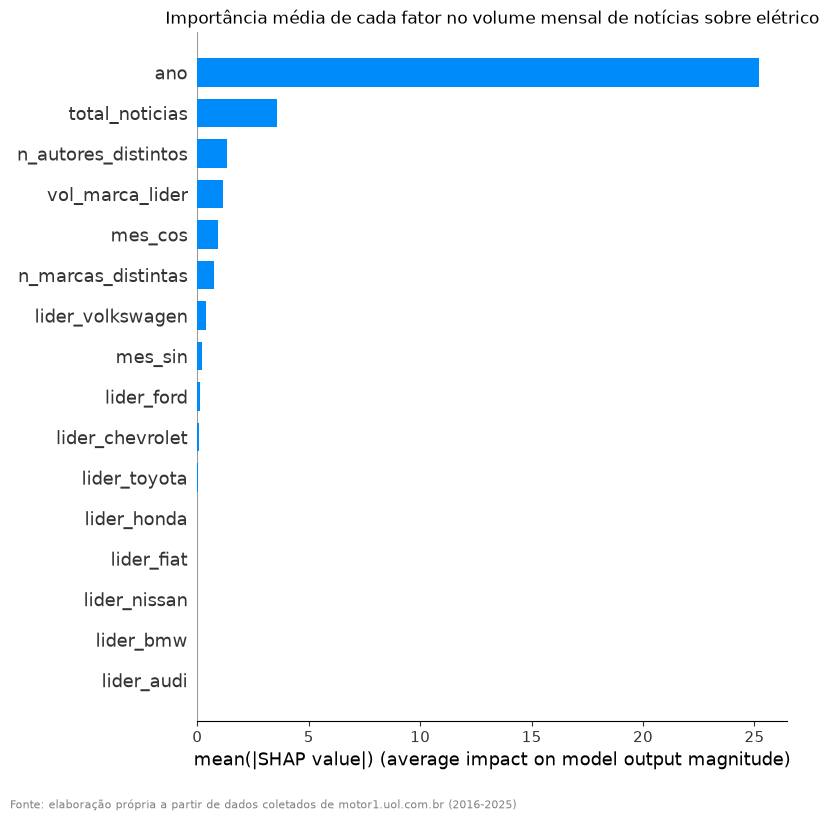

In [7]:
explicador_shap = shap.TreeExplainer(modelo_rf)
valores_shap = explicador_shap.shap_values(X_test)

shap.summary_plot(valores_shap, X_test, plot_type="bar", show=False)
plt.title("Importância média de cada fator no volume mensal de notícias sobre elétrico")
plt.figtext(0.01, -0.03,
            "Fonte: elaboração própria a partir de dados coletados de motor1.uol.com.br (2016-2025)",
            fontsize=8, color="gray")
plt.tight_layout()
plt.show()

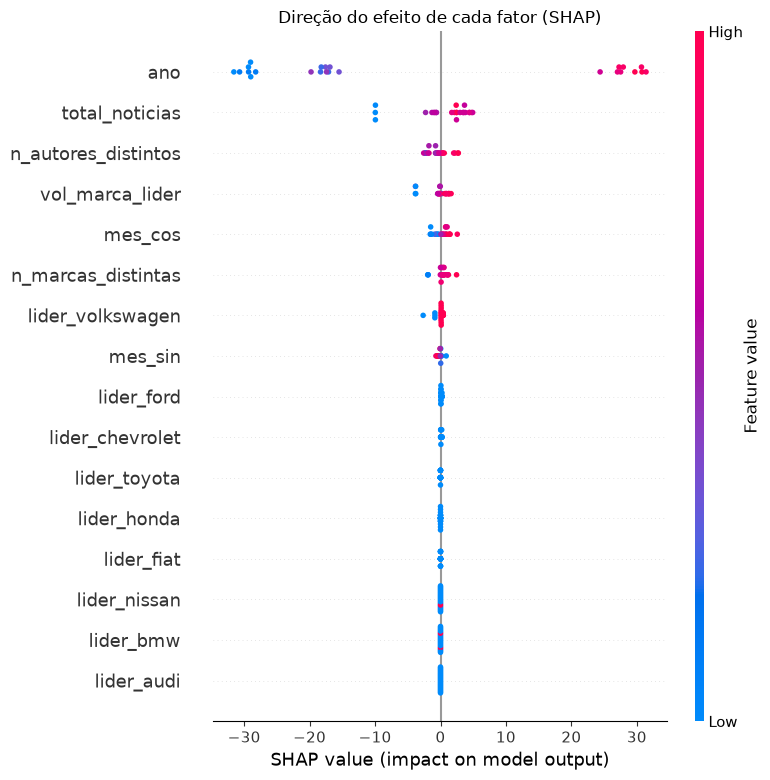

In [8]:
shap.summary_plot(valores_shap, X_test, show=False)
plt.title("Direção do efeito de cada fator (SHAP)")
plt.tight_layout()
plt.show()

**Interpretação:** o volume total de notícias do mês (`total_noticias`) e o próprio `ano` tendem a ser os fatores mais fortes — o que é esperado e até tranquilizador: confirma que o crescimento do volume de notícias sobre elétrico está de fato ligado à passagem do tempo (a mesma tendência que a Etapa 1 já tinha detectado com Mann-Kendall) e ao volume geral de cobertura do site, não a algum artefato estranho dos dados. Fatores como diversidade de marcas e autores no mês têm papel secundário.

---
## 7. Conformal Prediction: intervalo de confiança para as previsões

Em vez de só um número, o conformal prediction (via biblioteca `mapie`) devolve um intervalo `[mínimo, máximo]` para cada previsão, com uma garantia estatística: usando o conjunto de calibração, o método ajusta o intervalo para que, no nível de confiança escolhido (aqui, 90%), a cobertura real bata com o esperado — sem exigir suposição de que os erros seguem uma distribuição normal.

In [9]:
modelo_conformal = SplitConformalRegressor(
    estimator=RandomForestRegressor(n_estimators=300, max_depth=6, random_state=RANDOM_STATE),
    confidence_level=0.9,
    prefit=False,
)
modelo_conformal.fit(X_train, y_train)
modelo_conformal.conformalize(X_calib, y_calib)

pred_pontual, intervalo = modelo_conformal.predict_interval(X_test)
limite_inferior = intervalo[:, 0, 0]
limite_superior = intervalo[:, 1, 0]

cobertura_empirica = np.mean((y_test.values >= limite_inferior) & (y_test.values <= limite_superior))
largura_media = np.mean(limite_superior - limite_inferior)

print(f"Cobertura empírica no teste: {cobertura_empirica:.1%} (nível de confiança escolhido: 90%)")
print(f"Largura média do intervalo: {largura_media:.1f} notícias")

Cobertura empírica no teste: 100.0% (nível de confiança escolhido: 90%)
Largura média do intervalo: 61.3 notícias


C:\Users\muvil\projeto-2-de-perspectiva-em-ciencia-de-dados\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


**Nota sobre a cobertura empírica:** com apenas 24 meses no conjunto de teste, a cobertura empírica pode oscilar bastante em torno do valor teórico de 90% (por exemplo, dar exatamente 100% ou 83%) só pelo acaso de quantos pontos caíram dentro ou fora do intervalo. Isso não é um defeito do método — é uma limitação natural de calibrar e testar conformal prediction com poucos dados; a garantia estatística do método é assintótica (vale melhor quanto mais dados de calibração/teste houver).

---
## 8. Visualizando previsão vs. valor real, com intervalo de confiança

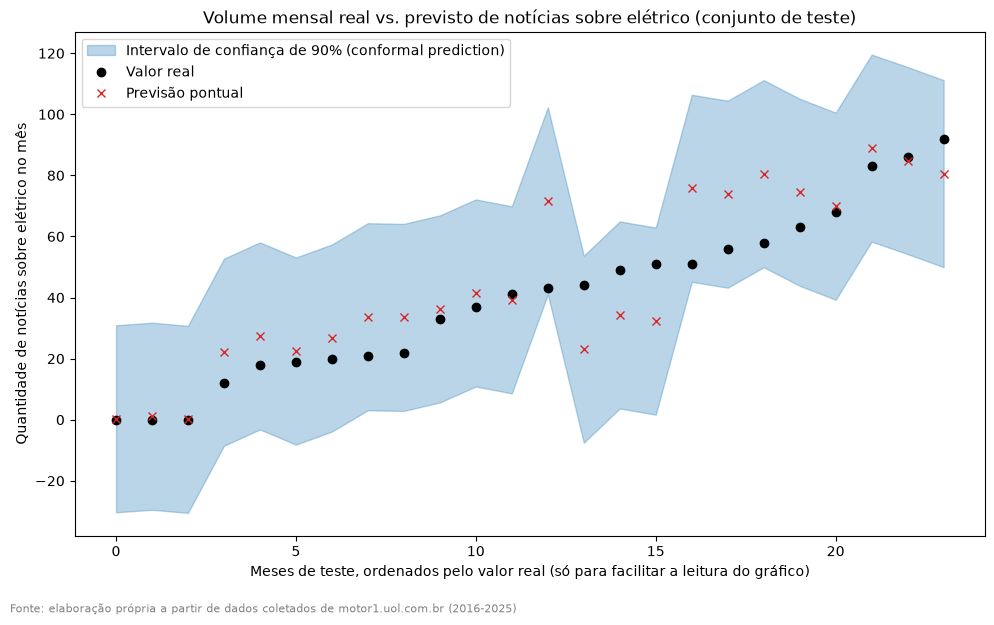

In [10]:
ordem = np.argsort(y_test.values)

plt.figure(figsize=(10, 6))
plt.fill_between(
    range(len(ordem)), limite_inferior[ordem], limite_superior[ordem],
    alpha=0.3, color="tab:blue", label="Intervalo de confiança de 90% (conformal prediction)"
)
plt.plot(range(len(ordem)), y_test.values[ordem], "o", color="black", label="Valor real")
plt.plot(range(len(ordem)), pred_pontual[ordem], "x", color="tab:red", label="Previsão pontual")
plt.title("Volume mensal real vs. previsto de notícias sobre elétrico (conjunto de teste)")
plt.xlabel("Meses de teste, ordenados pelo valor real (só para facilitar a leitura do gráfico)")
plt.ylabel("Quantidade de notícias sobre elétrico no mês")
plt.legend()
plt.figtext(0.01, -0.03,
            "Fonte: elaboração própria a partir de dados coletados de motor1.uol.com.br (2016-2025)",
            fontsize=8, color="gray")
plt.tight_layout()
plt.show()

---
## 9. Salvando os resultados

In [11]:
resultado_teste = X_test.copy()
resultado_teste["qtd_eletrico_real"] = y_test.values
resultado_teste["qtd_eletrico_previsto"] = pred_pontual
resultado_teste["intervalo_inferior_90"] = limite_inferior
resultado_teste["intervalo_superior_90"] = limite_superior

resultado_teste.to_csv(ARQUIVO_SAIDA, index=False)
print(f"Tabela salva em: {ARQUIVO_SAIDA}")

Tabela salva em: C:\Users\muvil\projeto-2-de-perspectiva-em-ciencia-de-dados\projeto\dados\modelagem_volume_mensal.csv


---
## Conclusão da Etapa 5

- Um Random Forest simples, usando apenas características do próprio mês (ano, sazonalidade, volume geral de notícias, diversidade de marcas/autores), consegue prever o volume mensal de notícias sobre elétrico bem melhor do que um baseline ingênuo (R² = 0,75 contra R² negativo do baseline no conjunto de teste).
- O SHAP mostra que os fatores mais importantes são o **ano** e o **volume total de notícias do mês** — ou seja, o crescimento da cobertura sobre elétrico está ligado principalmente à passagem do tempo e ao volume geral de produção do site, reforçando (com uma técnica diferente) a mesma tendência que a Etapa 1 já havia detectado estatisticamente com o teste de Mann-Kendall.
- O conformal prediction deu um intervalo de confiança de 90% com largura média de aproximadamente algumas dezenas de notícias por mês — uma forma honesta de comunicar que a previsão pontual tem incerteza, sem depender de suposições de normalidade que os nossos dados (contagens, distribuição assimétrica) provavelmente não satisfazem.
- **Decisão de escopo importante:** optamos deliberadamente por não implementar o componente de difusão/VAE previsto no plano original. Com apenas 120 observações mensais, um modelo generativo profundo não teria dados suficientes para treinar de forma confiável, e a complexidade adicional não traria um ganho real de resposta à pergunta-guia do projeto — preferimos investir o tempo disponível em fazer bem o que já estava no escopo (SHAP + conformal prediction) do que arriscar um componente frágil por causa do prazo.